In [35]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_selection import VarianceThreshold

from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Lasso

from sklearn.neighbors import KNeighborsRegressor

In [2]:
# Upload manually cleaning data
from google.colab import files
uploaded = files.upload()

Saving design_matrix_ver_1.csv to design_matrix_ver_1.csv


In [3]:
df = pd.read_csv("design_matrix_ver_1.csv")
df = df.set_index(['HEATID', 'DATETIME'])
df.head()

,,16A,25A,25A1,26A,3A,3A (shop pipe waste),3ACh,3B23,Aluminum briquet,Artificial graphite 0.1-2.5 mm,...,VALNI,VALAS,VALSN,VALN,TEMP,VALO2_PPM,O2_AMOUNT,GAS_AMOUNT,INJ_AMOUNT_CARBON,MW
HEATID,DATETIME,,,,,,,,,,,,,,,,,,,,,
5F0002,2015-01-01 01:31:00.000000000,0.0,0.0,0.0,0.0,105928.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,1627.0,383.000000,3659.0,1160.0,1021.0,48.625
5F0003,2015-01-01 02:17:30.000000000,0.0,0.0,0.0,0.0,108033.0,0.0,0.0,0.0,0.0,0.0,...,0.1075,0.0053,0.0068,0.0361,1641.0,683.000000,3469.0,1117.0,957.0,48.625
5F0004,2015-01-01 03:17:30.000000000,0.0,0.0,0.0,0.0,128245.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,1636.0,700.000000,3605.0,1204.0,789.0,47.375
5F0005,2015-01-01 04:06:00.000000000,0.0,0.0,0.0,0.0,106941.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,1630.0,625.333333,3678.0,1191.0,812.0,49.250
5F0006,2015-01-01 04:54:24.000000000,0.0,0.0,0.0,0.0,127035.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,1622.0,654.600000,3655.0,1171.0,882.0,49.875


In [4]:
# Remove features with perfectly 0 variance
df = df.drop(columns=df.columns[df.var(axis='rows') == 0])

# Split the dataset into those with or without steel chemistry.
# For now, remove the steel chemistry feature as it is mostly (~85%) empty.
df = df[df['VALC'].isna()]

# Drop columns that are all NaN
df = df.dropna(axis='columns', how='all')

# Drop rows that contain any NaN
df = df.dropna(axis='rows')

# Define feature and target columns
FEATURES = list(df.columns[:-1])
TARGET = 'MW'

df.describe()

,16A,25A,25A1,26A,3A,3ACh,3B23,Aluminum briquet,Artificial graphite 0.1-2.5 mm,B11,...,Secondary aluminum AV 87 Added,Steel scrap G/B 25A Added,total_charging_time,num_baskets,TEMP,VALO2_PPM,O2_AMOUNT,GAS_AMOUNT,INJ_AMOUNT_CARBON,MW
count,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,...,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000
mean,5046.419135,136.103542,2292.335285,11.216368,113957.310271,1066.367157,2.877654,0.011531,7.033292,147.269824,...,3.791319,0.590148,2659.102359,2.068299,1635.502847,982.395617,4292.221335,762.949441,901.256519,48.570531
std,4942.693717,904.675505,4836.046339,316.184722,25724.755668,5536.199276,154.345988,1.088153,76.715107,2408.968325,...,185.910261,76.744259,8917.298415,0.350561,16.725183,698.369872,501.586274,150.643999,311.330350,8.787742
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,1517.000000,1.000000,0.000000,0.000000,0.000000,-999.999000
25%,0.000000,0.000000,0.000000,0.000000,109894.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1020.000000,2.000000,1624.500000,726.125000,3958.000000,664.000000,696.000000,47.250000
50%,5060.000000,0.000000,0.000000,0.000000,121168.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1080.000000,2.000000,1635.000000,862.000000,4274.000000,752.000000,886.000000,48.750000
75%,9253.500000,0.000000,0.000000,0.000000,127959.500000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1260.000000,2.000000,1646.000000,996.000000,4598.000000,838.000000,1084.000000,50.375000
max,49366.000000,20854.000000,24776.000000,13890.000000,139916.000000,69506.000000,10052.000000,120.000000,1900.000000,76639.000000,...,24000.000000,9980.000000,86160.000000,8.000000,1737.000000,9999.000000,8886.000000,2209.000000,10884.000000,85.000000


In [5]:
# Filter physically impossible MW values (based on process knowledge)
df = df[(df['MW'] > 35) & (df['MW'] < 70)]

In [6]:
# Train/test split
df_train, df_test = train_test_split(df, train_size=0.7)

df_train.describe()

,16A,25A,25A1,26A,3A,3ACh,3B23,Aluminum briquet,Artificial graphite 0.1-2.5 mm,B11,...,Secondary aluminum AV 87 Added,Steel scrap G/B 25A Added,total_charging_time,num_baskets,TEMP,VALO2_PPM,O2_AMOUNT,GAS_AMOUNT,INJ_AMOUNT_CARBON,MW
count,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.0,11740.000000,11740.000000,...,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000
mean,5065.771039,139.164310,2288.479131,11.053663,114297.500596,1024.834412,3.528024,0.0,6.665247,139.578535,...,2.419421,0.850085,2512.993186,2.070017,1635.465489,984.511075,4307.064395,764.523765,902.853237,48.782943
std,4957.847877,915.549013,4813.776629,310.866446,25459.618360,5444.117414,172.755826,0.0,72.739668,2341.523144,...,24.548008,92.107818,8423.095607,0.336906,16.551715,705.965650,480.517270,147.599164,311.487422,2.826180
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,1517.000000,1.333333,2640.000000,360.000000,0.000000,35.250000
25%,0.000000,0.000000,0.000000,0.000000,110445.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,1020.000000,2.000000,1624.666667,724.916667,3971.000000,665.000000,697.000000,47.250000
50%,5070.000000,0.000000,0.000000,0.000000,121250.500000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,1080.000000,2.000000,1635.000000,860.600000,4282.000000,754.000000,885.500000,48.750000
75%,9280.000000,0.000000,0.000000,0.000000,127981.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,1260.000000,2.000000,1646.000000,996.343750,4607.000000,839.000000,1086.000000,50.500000
max,35270.000000,20854.000000,24776.000000,13890.000000,139916.000000,66130.000000,10052.000000,0.0,1870.000000,76639.000000,...,1000.000000,9980.000000,86160.000000,8.000000,1723.500000,9999.000000,8886.000000,2209.000000,10884.000000,69.500000


In [7]:
df_test.describe()

,16A,25A,25A1,26A,3A,3ACh,3B23,Aluminum briquet,Artificial graphite 0.1-2.5 mm,B11,...,Secondary aluminum AV 87 Added,Steel scrap G/B 25A Added,total_charging_time,num_baskets,TEMP,VALO2_PPM,O2_AMOUNT,GAS_AMOUNT,INJ_AMOUNT_CARBON,MW
count,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,...,5032.000000,5032.0,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000
mean,5051.503180,129.925079,2297.590421,11.905803,114254.041733,1150.480922,1.439785,0.014905,8.086248,163.503180,...,7.066971,0.0,2915.067568,2.079690,1635.562529,975.504290,4291.265302,763.956280,900.917528,48.817369
std,4906.163796,879.715641,4871.951998,332.463571,25264.013139,5702.906822,102.133467,1.057282,86.212136,2558.285374,...,338.743032,0.0,9655.760323,0.343334,16.953400,678.720035,476.931054,152.173616,304.478627,2.733069
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,1.000000,1555.000000,1.000000,2632.000000,286.000000,47.000000,36.750000
25%,0.000000,0.000000,0.000000,0.000000,109677.750000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,1020.000000,2.000000,1624.276786,729.787500,3959.000000,664.000000,698.750000,47.250000
50%,5070.000000,0.000000,0.000000,0.000000,121324.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,1080.000000,2.000000,1635.000000,864.750000,4267.000000,750.000000,891.000000,48.750000
75%,9232.500000,0.000000,0.000000,0.000000,127970.250000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,1200.000000,2.000000,1646.000000,992.000000,4592.250000,835.000000,1076.250000,50.375000
max,49366.000000,14392.000000,24510.000000,10690.000000,139867.000000,69506.000000,7245.000000,75.000000,1900.000000,61870.000000,...,24000.000000,0.0,85500.000000,7.000000,1737.000000,9999.000000,7768.000000,2037.000000,5322.000000,65.000000


# Helper Function

In [8]:
def get_regression_metrics(model, X, y_true):   # This is the same evaluation function from tutorial 04, which we can also use here.
    """
    Get a dicionary with regression metrics:

    model: sklearn model with predict method
    X: feature matrix
    y_true: ground truth labels
    """
    y_predicted = model.predict(X)

    mae = np.sum(abs(y_true - y_predicted)) / len(y_true)
    mse = np.sum((y_true - y_predicted)**2) / len(y_true)
    maximum_error = np.max(abs(y_true - y_predicted))
    mape =  np.sum(abs((y_true - y_predicted)/y_true)) / len(y_true)

    metrics_dict = {
        'mae': mae,
        'mse': mse,
        'max_error': maximum_error,
        'mape': mape
    }

    return metrics_dict

In [9]:
def plot_predictions(model, X, y_true, title='Model Results'):
    '''
    Makes a scatterplot that compares y_true and y_predicted.

    model: sklearn model with predict method
    X: feature matrix
    y_true: ground truth labels
    '''

    fig, ax = plt.subplots()

    ax.scatter(
        y_true,
        model.predict(X),
        alpha=0.3
    )

    ax.plot(
        [-9999, 9999],
        [-9999, 9999]
    )

    ax.set_ylim(np.min(y_true), np.max(y_true))
    ax.set_xlim(np.min(y_true), np.max(y_true))

    ax.set_title(title)
    ax.set_xlabel('True Values')
    ax.set_ylabel('Predicted Values')
    plt.show()

# Kernel Ridge Regression (RBF) Model (Fiona)

In [10]:
# Define model
krr = KernelRidge(kernel='rbf')

In [11]:
# Set up pipeline
krr_pipeline = Pipeline([
    ('variance threshold', VarianceThreshold()),
    ('scaling', StandardScaler()),
    ('krr', krr)
])

In [12]:
# Define parameter grid
param_grid_krr = {
    'variance threshold__threshold': [0],
    'krr__alpha': [0.001, 0.01, 0.1, 1, 10],
    'krr__gamma': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
}

# Randomized search for best parameters
random_param_grid_krr = RandomizedSearchCV(
    krr_pipeline,
    param_distributions=param_grid_krr,
    n_iter=20,
    cv=5,
    verbose=2,
    n_jobs=-1
)

In [14]:
# Fit model
random_param_grid_krr.fit(df_train[FEATURES], df_train[TARGET])

Fitting 5 folds for each of 20 candidates, totalling 100 fits


KeyboardInterrupt: 

In [ ]:
# Display best model
print(random_param_grid_krr.best_estimator_)

Pipeline(steps=[('variance threshold', VarianceThreshold(threshold=0)),
                ('scaling', StandardScaler()),
                ('krr', KernelRidge(alpha=0.001, gamma=0.0001, kernel='rbf'))])


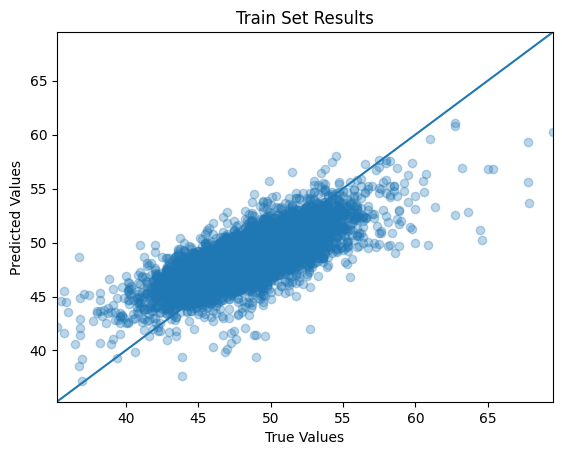

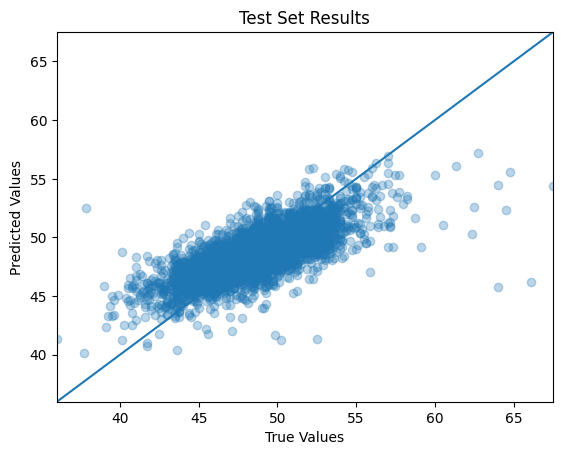

In [ ]:
# Plot predictions
plot_predictions(random_param_grid_krr.best_estimator_, df_train[FEATURES], df_train[TARGET], title='Train Set Results')
plot_predictions(random_param_grid_krr.best_estimator_, df_test[FEATURES], df_test[TARGET], title='Test Set Results')

In [ ]:
# Evaluate regression metrics
metrics_train = get_regression_metrics(random_param_grid_krr.best_estimator_, df_train[FEATURES], df_train[TARGET])
metrics_test = get_regression_metrics(random_param_grid_krr.best_estimator_, df_test[FEATURES], df_test[TARGET])

print("Training metrics:", metrics_train)
print("Test metrics:", metrics_test)

Training metrics: {'mae': np.float64(1.3819697555867665), 'mse': np.float64(3.473020212147746), 'max_error': 14.371243714813318, 'mape': np.float64(0.02852513051478651)}
Test metrics: {'mae': np.float64(1.3952809162096647), 'mse': np.float64(3.6310217516288708), 'max_error': 19.950679612375097, 'mape': np.float64(0.028649925851038153)}


# Linear Model -- Ridge Regression Model (Kelsy)

In [16]:
# Define Model
ridge = Ridge(random_state=42)

In [17]:
# Set up pipeline
ridge_pipeline = Pipeline([
    ('variance threshold', VarianceThreshold()),   # remove low variance feature
    ('scaling', StandardScaler()),                 # standardized
    ('ridge', ridge)
])

In [18]:
# Define parameter grid
param_grid_ridge = {
    'ridge__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]  # L2 正则化强度
}

# Randomized search for best parameters
ridge_search = RandomizedSearchCV(
    ridge_pipeline,
    param_distributions=param_grid_ridge,
    n_iter=7,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

In [20]:
# Fit model
ridge_search.fit(df_train[FEATURES], df_train[TARGET])

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('variance threshold',
                                              VarianceThreshold()),
                                             ('scaling', StandardScaler()),
                                             ('ridge',
                                              Ridge(random_state=42))]),
                   n_iter=7, n_jobs=-1,
                   param_distributions={'ridge__alpha': [0.0001, 0.001, 0.01,
                                                         0.1, 1, 10, 100]},
                   random_state=42, scoring='r2')

In [22]:
# Display best model
print("Best Ridge parameters:", ridge_search.best_params_)


Best Ridge parameters: {'ridge__alpha': 100}


In [24]:
# Ridge Model Performance
metrics_train_ridge = get_regression_metrics(ridge_search, df_train[FEATURES], df_train[TARGET])
metrics_test_ridge = get_regression_metrics(ridge_search, df_test[FEATURES], df_test[TARGET])
print("Train metrics:", metrics_train_ridge)
print("Test metrics:", metrics_test_ridge)

Train metrics: {'mae': np.float64(1.6801526776470694), 'mse': np.float64(5.1132703031274875), 'max_error': 18.348923240945602, 'mape': np.float64(0.03482283207241028)}
Test metrics: {'mae': np.float64(1.6465322834282934), 'mse': np.float64(4.793056694041779), 'max_error': 19.107440776399887, 'mape': np.float64(0.03399714739931136)}


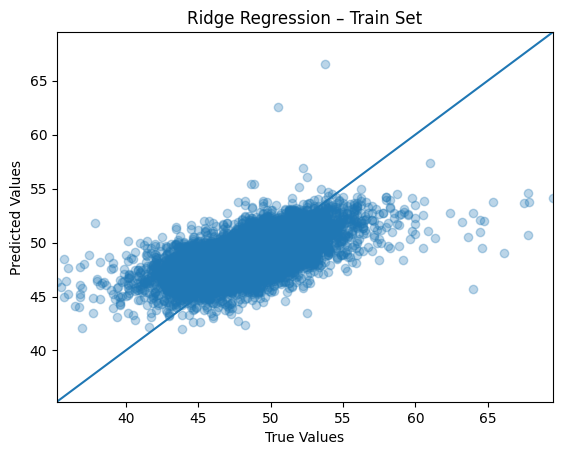

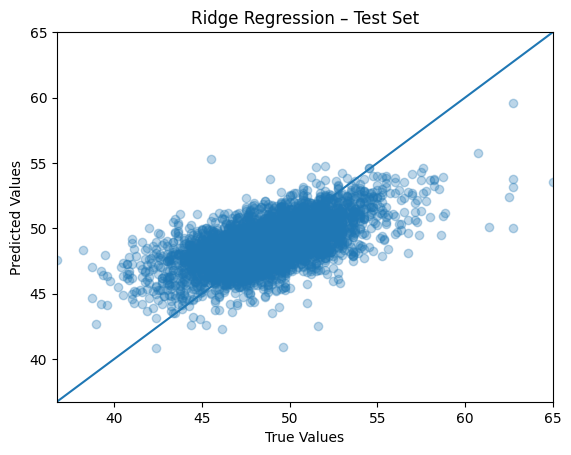

In [25]:
# Plot predictions
plot_predictions(ridge_search, df_train[FEATURES], df_train[TARGET], title="Ridge Regression – Train Set")
plot_predictions(ridge_search, df_test[FEATURES], df_test[TARGET], title="Ridge Regression – Test Set")

# Linear Model -- Lasso Regression (Kelsy)

In [28]:
# Define Model
lasso = Lasso(max_iter=10000, random_state=42)

In [29]:
# Set up pipeline
lasso_pipeline = Pipeline([
    ('variance threshold', VarianceThreshold()),
    ('scaling', StandardScaler()),
    ('lasso', lasso)
])

In [30]:
# Define Parameter Grid
param_grid_lasso = {
    'lasso__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

lasso_search = RandomizedSearchCV(
    lasso_pipeline,
    param_distributions=param_grid_lasso,
    n_iter=6,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

In [31]:
# Fit Model
lasso_search.fit(df_train[FEATURES], df_train[TARGET])

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('variance threshold',
                                              VarianceThreshold()),
                                             ('scaling', StandardScaler()),
                                             ('lasso',
                                              Lasso(max_iter=10000,
                                                    random_state=42))]),
                   n_iter=6, n_jobs=-1,
                   param_distributions={'lasso__alpha': [0.0001, 0.001, 0.01,
                                                         0.1, 1, 10]},
                   random_state=42, scoring='r2')

In [32]:
# Display best model
print("Best Lasso parameters:", lasso_search.best_params_)

Best Lasso parameters: {'lasso__alpha': 0.001}


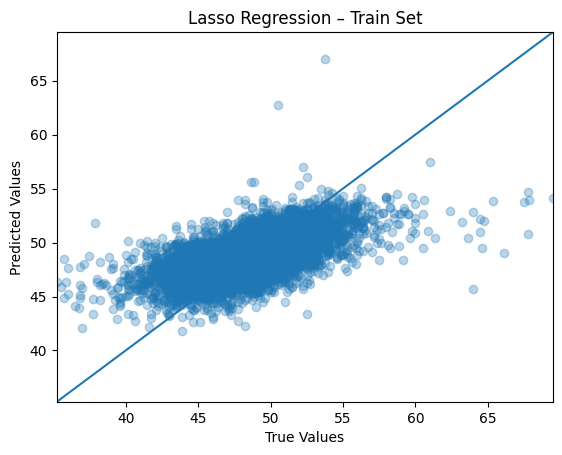

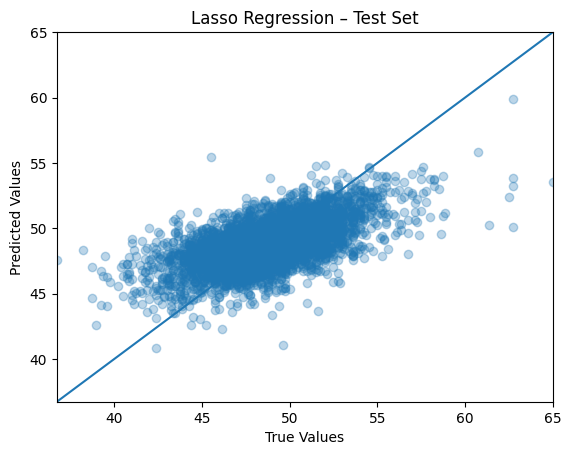

In [33]:
# Plot predictions
plot_predictions(lasso_search, df_train[FEATURES], df_train[TARGET], title="Lasso Regression – Train Set")
plot_predictions(lasso_search, df_test[FEATURES], df_test[TARGET], title="Lasso Regression – Test Set")

In [34]:
# Evaluate Lasso Performance
metrics_train_lasso = get_regression_metrics(lasso_search, df_train[FEATURES], df_train[TARGET])
metrics_test_lasso = get_regression_metrics(lasso_search, df_test[FEATURES], df_test[TARGET])
print("Train metrics:", metrics_train_lasso)
print("Test metrics:", metrics_test_lasso)

Train metrics: {'mae': np.float64(1.6809528599342185), 'mse': np.float64(5.112365169339531), 'max_error': 18.292441611106298, 'mape': np.float64(0.03483661675601034)}
Test metrics: {'mae': np.float64(1.6460871059487867), 'mse': np.float64(4.785622577161154), 'max_error': 18.964721778321987, 'mape': np.float64(0.033987399547268766)}


# KNN Model (Kelsy)

In [36]:
# Define model
knn = KNeighborsRegressor()

In [37]:
# Set up pipeline
knn_pipeline = Pipeline([
    ('variance threshold', VarianceThreshold()),  # remove near and constant features
    ('scaling', StandardScaler()),
    ('knn', knn)
])

In [38]:
# Define Parameter Grid
param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 20],
    'knn__weights': ['uniform', 'distance'],      #equal weight + closer neighbors weigh more
    'knn__p': [1, 2]
}

knn_search = RandomizedSearchCV(
    knn_pipeline,
    param_distributions=param_grid_knn,
    n_iter=10,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

In [39]:
# Train model
knn_search.fit(df_train[FEATURES], df_train[TARGET])

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('variance threshold',
                                              VarianceThreshold()),
                                             ('scaling', StandardScaler()),
                                             ('knn', KNeighborsRegressor())]),
                   n_jobs=-1,
                   param_distributions={'knn__n_neighbors': [3, 5, 7, 9, 11, 15,
                                                             20],
                                        'knn__p': [1, 2],
                                        'knn__weights': ['uniform',
                                                         'distance']},
                   random_state=42, scoring='r2')

In [40]:
# Display best model
print("Best KNN parameters:", knn_search.best_params_)

Best KNN parameters: {'knn__weights': 'distance', 'knn__p': 1, 'knn__n_neighbors': 7}


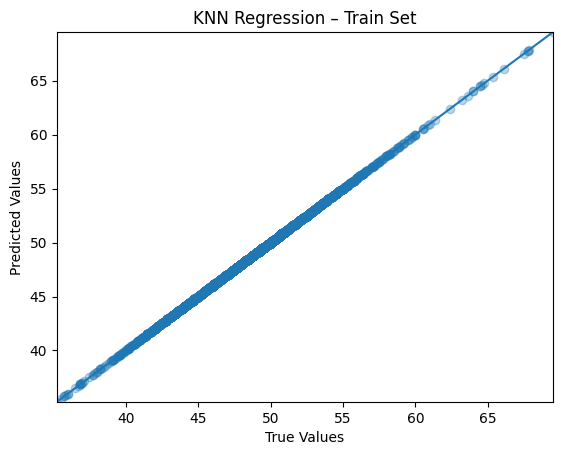

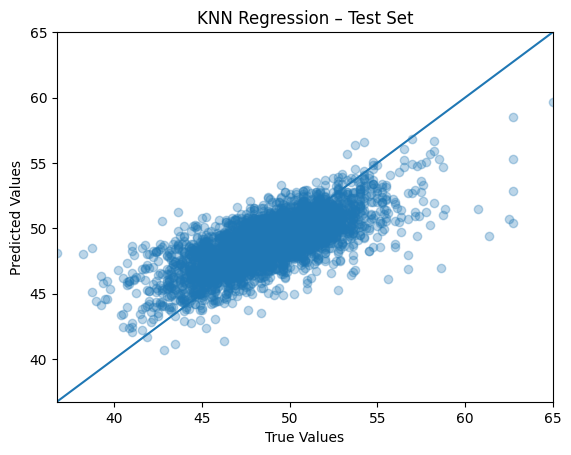

In [41]:
# Plot predictions

plot_predictions(knn_search, df_train[FEATURES], df_train[TARGET], title="KNN Regression – Train Set")
plot_predictions(knn_search, df_test[FEATURES], df_test[TARGET], title="KNN Regression – Test Set")

In [42]:
# Evaluate KNN Performance
metrics_train_knn = get_regression_metrics(knn_search, df_train[FEATURES], df_train[TARGET])
metrics_test_knn = get_regression_metrics(knn_search, df_test[FEATURES], df_test[TARGET])

print("Train metrics:", metrics_train_knn)
print("Test metrics:", metrics_test_knn)

Train metrics: {'mae': np.float64(0.0), 'mse': np.float64(0.0), 'max_error': 0.0, 'mape': np.float64(0.0)}
Test metrics: {'mae': np.float64(1.401070176537212), 'mse': np.float64(3.678112472708933), 'max_error': 12.347578707241993, 'mape': np.float64(0.028917348997847998)}
